# Task 1: Customer Feedback Cassification

For this task I am using pyTorch to build a customer transformer model to classify text into five catagories.
- Missed collection
- Service complaint
- Damaged property
- General inquery 
- Positive feedback

This is following the NLP pipeline
- Preprocess text
- Convert text to features
- Train a classifier
- Generate predictionson
- Evaluate
- Error Analysis

I am also using pandas for data manipulations and Scikit-learn for my evaluation metrics

In [1]:
# Cell 1: Imports and environment setup
import os
import re
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Initialise device
device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# File paths (ensure your 'data' directory is set up correctly)
DATA_DIR = os.path.join(os.getcwd(), 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Test.csv')

Device: cuda


## Preprocessing and Exploratory Data Analysis (EDA)
Data cleaning and analysis form the foundation of our pipeline. My choices here were designed to optimize the model's learning efficiency:

* **Text Cleaning:** Using Regular Expressions (`re`), I removed special characters and normalized whitespace, while converting text to lowercase. This standardizes the input, preventing the model from treating "Bin!" and "bin" as two completely different words, thereby reducing the vocabulary size and noise.
* **Dynamic Sequence Length (95th Percentile):** Transformer models require fixed-length input tensors. Rather than arbitrarily picking a maximum length or using the absolute maximum (168 words) which would result in excessive zero-padding and wasted computational power, I used EDA to find the **95th percentile** of message lengths (76 words). Capping the sequence length here ensures we retain the complete context for 95% of our data while significantly speeding up training time and saving memory.

In [2]:
# Cell 2: Load the training and testing data
train_df = pd.read_csv(TRAIN_CSV).dropna(subset=['message', 'label']).reset_index(drop=True)
val_df = pd.read_csv(TEST_CSV).dropna(subset=['message', 'label']).reset_index(drop=True)

print(f'Loaded {len(train_df)} training rows')
print(f'Loaded {len(val_df)} testing rows (used for validation)')

# Apply the cleaning to both dataframes immediately
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

train_df['text'] = train_df['message'].apply(clean_text)
val_df['text'] = val_df['message'].apply(clean_text)

# We still use the training set to determine our "normal" message length
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

Loaded 2119 training rows
Loaded 904 testing rows (used for validation)


C:\Users\fynle\AppData\Local\Temp\ipykernel_13376\1152060621.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y='label', order=train_df['label'].value_counts().index,
C:\Users\fynle\AppData\Local\Temp\ipykernel_13376\1152060621.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=val_df, y='label', order=val_df['label'].value_counts().index,


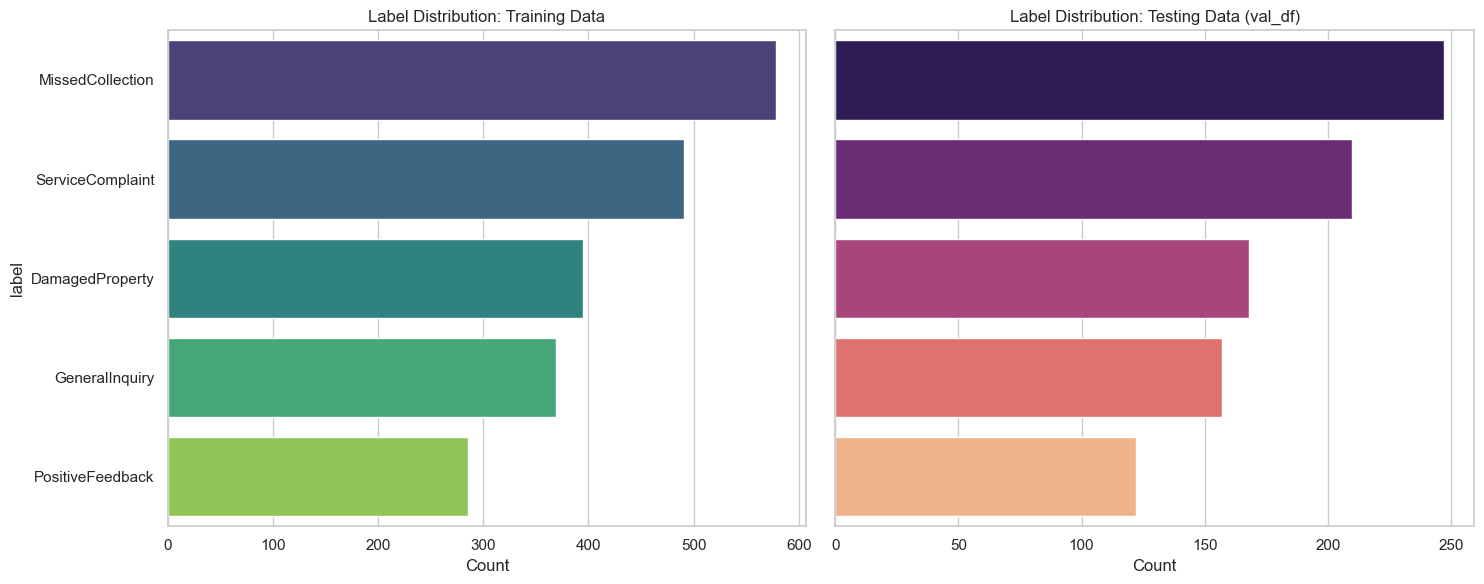

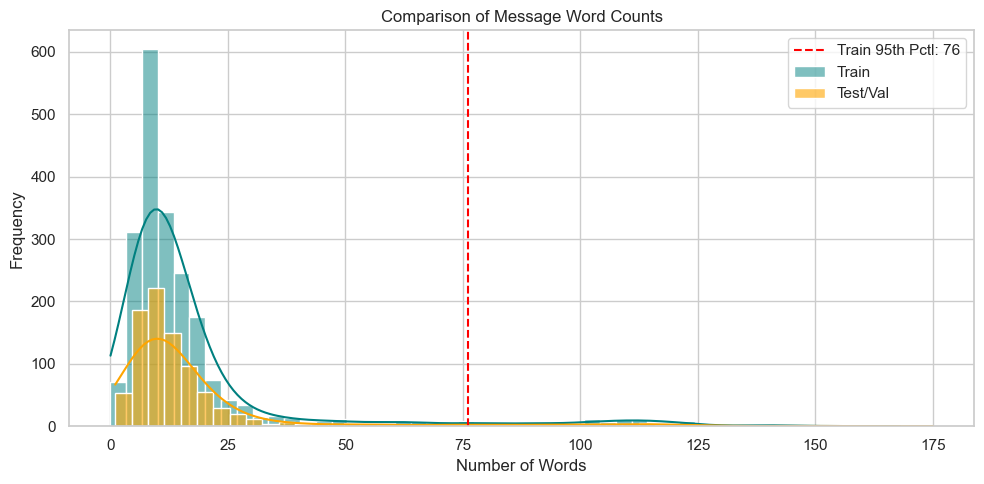

--- Training Word Count Stats ---
count    2119.000000
mean       17.998584
std        23.073465
min         0.000000
25%         7.000000
50%        11.000000
75%        17.000000
max       168.000000
Name: word_count, dtype: float64

--- Testing Word Count Stats ---
count    904.000000
mean      17.835177
std       22.957818
min        1.000000
25%        7.000000
50%       11.000000
75%       17.000000
max      175.000000
Name: word_count, dtype: float64


In [3]:
# Cell 3: Exploratory Data Analysis (EDA)
sns.set_theme(style="whitegrid")

# 1. Compare Class Distributions between Train and Test
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Training Distribution
sns.countplot(data=train_df, y='label', order=train_df['label'].value_counts().index, 
              palette='viridis', ax=axes[0])
axes[0].set_title('Label Distribution: Training Data')
axes[0].set_xlabel('Count')

# Testing/Validation Distribution
sns.countplot(data=val_df, y='label', order=val_df['label'].value_counts().index, 
              palette='magma', ax=axes[1])
axes[1].set_title('Label Distribution: Testing Data (val_df)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# 2. Re-calculate word counts for both (cleaning was done in Cell 2)
val_df['word_count'] = val_df['text'].apply(lambda x: len(x.split()))

# 3. Visualise word counts to verify MAX_LEN remains appropriate
plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='teal', label='Train')
sns.histplot(val_df['word_count'], bins=50, kde=True, color='orange', label='Test/Val', alpha=0.6)

plt.title('Comparison of Message Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Mark the 95th Percentile from Training (which we use for MAX_LEN)
train_95th = train_df['word_count'].quantile(0.95)
plt.axvline(train_95th, color='red', linestyle='dashed', label=f"Train 95th Pctl: {train_95th:.0f}")

plt.legend()
plt.tight_layout()
plt.show()

print("--- Training Word Count Stats ---")
print(train_df['word_count'].describe())
print("\n--- Testing Word Count Stats ---")
print(val_df['word_count'].describe())

# What the Exploritary Data Analysis shows

This data analysis has shown that it is an unbalanced dataset where there would be a bias towards missed collection over positive feeback as there is a large difference in quantity between them. this means that the recognisation of a missed colection message will be easier to identify over the positive feedback.
This also shows that there is a lack in diverity in relavance to the length of the message with the mean being 18 words per message with a major outlire of 168 words.

The descriptive statistics show that while the maximum message length is 168 words, 75% of the data is under 17 words. To optimize training efficiency and avoid excessive padding, I capped the maximum sequence length at the 95th percentile.

In [12]:
# Cell 4: Label Mapping and Sequence Length Setup

# 1. Map labels to indices based on the training set
labels = sorted(train_df['label'].unique())
label2idx = {l: i for i, l in enumerate(labels)}
idx2label = {i: l for l, i in label2idx.items()}
print('Labels mapping:', label2idx)

# Apply label mapping to both sets
train_df['label_idx'] = train_df['label'].map(label2idx)
val_df['label_idx'] = val_df['label'].map(label2idx)

# Verify no NaNs were created by the mapping
val_df = val_df.dropna(subset=['label_idx'])
val_df['label_idx'] = val_df['label_idx'].astype(int) 

# 2. Calculate MAX_LEN from training data (95th percentile from EDA)
MAX_LEN = int(train_df['word_count'].quantile(0.95))
MAX_LEN = max(50, MAX_LEN) 
print(f'Using MAX_LEN: {MAX_LEN}')

Labels mapping: {'DamagedProperty': 0, 'GeneralInquiry': 1, 'MissedCollection': 2, 'PositiveFeedback': 3, 'ServiceComplaint': 4}
Using MAX_LEN: 76


## Model Architecture Selection: Why BERT?
For this text classification task, I chose to implement a **Transformer-based model (BERT - Bidirectional Encoder Representations from Transformers)** rather than traditional deep learning models like Convolutional Neural Networks (CNNs) or Recurrent Neural Networks (RNNs/LSTMs). 

* **Contextual Understanding:** CNNs are excellent at extracting local, contiguous features, and RNNs process text sequentially. However, BERT reads the entire sequence bidirectionally at once using the Self-Attention mechanism. This allows the model to understand the deep, contextual meaning of words based on their surrounding text, which is vital for nuanced customer feedback.
* **Pre-trained Knowledge:** `bert-base-uncased` has been pre-trained on a massive corpus of English text. By using transfer learning, we start with a model that already understands language structure and grammar, requiring only fine-tuning for our specific 5-category classification task. This yields much higher accuracy with less training data compared to training a CNN from scratch.

## Tokenization: The BERT Tokenizer
Instead of a standard word-level split, this pipeline utilizes the `BertTokenizer`. 
* **WordPiece Tokenization:** BERT uses a subword tokenization algorithm. If it encounters a rare or misspelled word, it breaks it down into known subwords (e.g., "overflowing" might become "over", "##flow", "##ing"). This brilliantly handles out-of-vocabulary (OOV) issues common in messy customer data.
* **Special Tokens and Masks:** The tokenizer automatically formats our text to BERT's exact specifications. It prepends a `[CLS]` (classification) token to the start of the sequence and a `[SEP]` token at the end. Crucially, it also generates an **Attention Mask**, which explicitly tells the BERT model to ignore the `<pad>` tokens, preventing empty space from skewing the self-attention calculations.

In [13]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

# Use the standard BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # CHANGED: Call the tokenizer directly instead of .encode_plus()
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [6]:
# Map string labels to integer indices
train_df['label_idx'] = train_df['label'].map(label2idx)
val_df['label_idx'] = val_df['label'].map(label2idx)

# 1. Create the new BERT-compatible Datasets
train_dataset = BERTDataset(train_df['text'].values, train_df['label_idx'].values, tokenizer, MAX_LEN)
val_dataset = BERTDataset(val_df['text'].values, val_df['label_idx'].values, tokenizer, MAX_LEN)

# 2. Create the new DataLoaders
# BERT models are heavy; if you get a "CUDA Out of Memory" error, 
# try reducing batch_size to 16 or 8.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("✅ BERT Datasets and DataLoaders initialized successfully.")

✅ BERT Datasets and DataLoaders initialized successfully.


## Custom Classifier and Regularization (Dropout)
The custom `BertClassifier` class wraps the pre-trained BERT model and adapts it for our specific 5-class problem.

* **The [CLS] Token:** I extract the `pooler_output`, which corresponds to the embedding of the `[CLS]` token. In BERT's architecture, this specific token aggregates the entire sequence's representation, making it the perfect feature vector to pass into our final classification layer.
* **Dropout (0.2):** Before passing the aggregated features to the final Linear layer, I apply Dropout. This regularization technique randomly zeroes out 20% of the neurons during each training pass. This prevents the model from relying too heavily on any single feature or specific words, forcing it to learn robust, generalized patterns and mitigating overfitting.

In [7]:
from transformers import BertModel

class BertClassifier(nn.Module):
    def __init__(self, model_name='bert-base-uncased', num_classes=5, dropout=0.2):
        super(BertClassifier, self).__init__()
        
        # 1. Load the pre-trained BERT model
        self.bert = BertModel.from_pretrained(model_name)
        
        # 2. Add a dropout layer and a classification head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        """
        BERT takes input_ids and an attention_mask (to ignore padding).
        """
        # 3. Pass inputs through BERT
        # output.last_hidden_state: (batch, seq_len, 768)
        # output.pooler_output: (batch, 768) -> This is the [CLS] token representation
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # We use the 'pooler_output' which is the embedding of the [CLS] token
        # passed through a linear layer and a Tanh activation.
        pooled_output = outputs.pooler_output
        
        # 4. Final classification
        out = self.dropout(pooled_output)
        logits = self.fc(out)
        
        return logits

# Initialize the model
# 'bert-base-uncased' has an embed_dim (hidden_size) of 768
model_name = 'bert-base-uncased'
model = BertClassifier(
    model_name=model_name,
    num_classes=len(labels),
    dropout=0.2
).to(device)

print(model)

C:\Users\fynle\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fynle\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10099.17it/s]
BertModel LOAD REPORT from: bert-base-

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [ ]:
# Define Early Stopping and Training/Evaluation Loops
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, score, model):
        # Higher score (accuracy) is better
        if self.best_score is None or (score - self.best_score) > self.min_delta:
            self.best_score = score
            self.num_bad_epochs = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False 
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                return True
            return False

    def load_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        
        loss = criterion(logits, labels)
        loss.backward()
        
        # Clip gradients to prevent "exploding gradients" in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        
    return total_loss / len(data_loader), correct / len(data_loader.dataset)

def eval_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            
            # Save predictions and labels for evaluation metrics
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return total_loss / len(data_loader), correct / len(data_loader.dataset), all_preds, all_labels

## Training Optimization: Optimizer, Scheduler, and Early Stopping
Training large language models requires careful hyperparameter management to prevent catastrophic forgetting or overfitting:

* **Optimizer (AdamW):** I used AdamW instead of standard Adam. The "W" stands for Weight Decay (L2 regularization), which penalizes excessively large weights in the model, keeping the decision boundaries smoother and improving generalization.
* **Learning Rate Scheduler (`ReduceLROnPlateau`):** As the model gets closer to the optimal solution, taking large learning steps can cause it to overshoot. The scheduler monitors validation loss; if it stops improving, it halves the learning rate, allowing the model to take smaller, more precise steps to find the minimum loss.
* **Early Stopping:** Training for a fixed 100 epochs usually leads to overfitting. Early Stopping acts as a safety net. It monitors the validation accuracy, automatically saving the best model weights. If the model fails to improve after 10 epochs (patience), it halts training entirely, saving time and returning the most generalized version of the model.

In [ ]:
# Run the Training Loop

# 1. Label smoothing prevents the model from becoming overconfident
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Add weight_decay to the optimizer for L2 regularisation
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)

# 3. Add a Learning Rate Scheduler (Removed the deprecated 'verbose=True')
# This will reduce the learning rate by half (factor=0.5) if val_loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

best_val = 0.0
early_stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

os.makedirs(DATA_DIR, exist_ok=True)
ckpt_path = os.path.join(DATA_DIR, 'transformer_checkpoint.pth')

# Keep track of the learning rate so we can print when it changes
current_lr = optimizer.param_groups[0]['lr']

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Manually check if the learning rate dropped and print it
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f"\n📉 Learning rate dropped from {current_lr:.2e} to {new_lr:.2e}\n")
        current_lr = new_lr
    
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    
    # Save checkpoint on improvement
    if val_acc > best_val + MIN_DELTA:
        best_val = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'label2idx': label2idx,
            'idx2label': idx2label,
            'max_len': MAX_LEN
        }, ckpt_path)
        print(' -> Saved best model')
        
    if early_stopper.step(val_acc, model):
        print(f"Early stopping triggered (no validation accuracy improvement for {PATIENCE} epochs).")
        break

early_stopper.load_best(model)

Epoch 01: train_loss=1.2975, train_acc=0.5045 | val_loss=0.8696, val_acc=0.8905
 -> Saved best model
Epoch 02: train_loss=0.6514, train_acc=0.9118 | val_loss=0.5401, val_acc=0.9292
 -> Saved best model
Epoch 03: train_loss=0.4622, train_acc=0.9740 | val_loss=0.5035, val_acc=0.9524
 -> Saved best model
Epoch 04: train_loss=0.4150, train_acc=0.9924 | val_loss=0.4998, val_acc=0.9502
Epoch 05: train_loss=0.4021, train_acc=0.9967 | val_loss=0.5132, val_acc=0.9491
Epoch 06: train_loss=0.3962, train_acc=0.9981 | val_loss=0.5251, val_acc=0.9491
Epoch 07: train_loss=0.3950, train_acc=0.9991 | val_loss=0.5057, val_acc=0.9513
Epoch 08: train_loss=0.3931, train_acc=1.0000 | val_loss=0.4971, val_acc=0.9602
 -> Saved best model
Epoch 09: train_loss=0.3928, train_acc=1.0000 | val_loss=0.5007, val_acc=0.9569
Epoch 10: train_loss=0.3924, train_acc=1.0000 | val_loss=0.4989, val_acc=0.9602
Epoch 11: train_loss=0.3923, train_acc=1.0000 | val_loss=0.4976, val_acc=0.9602
Epoch 12: train_loss=0.3921, train_a

## Final Evaluation: Interpreting the Results
Because our EDA showed an imbalanced dataset (e.g., Missed Collections heavily outnumber Positive Feedback), relying purely on raw "Accuracy" is misleading. Therefore, I utilized robust evaluation metrics:

* **Classification Report (Precision, Recall, F1-Score):** * **Precision:** When the model predicts a "Service Complaint", how often is it actually correct?
    * **Recall:** Out of all the actual "Service Complaints" in the data, how many did the model successfully find?
    * **F1-Score:** The harmonic mean of precision and recall. It is the best metric for imbalanced data, ensuring the model performs well across *all* classes, not just the majority class.
* **Confusion Matrix:** This heatmap allows us to visualize exactly *where* the model gets confused. We can see if it frequently misclassifies "Damaged Property" as "Service Complaints", highlighting potential ambiguities in the customer text itself.
* **ROC-AUC (Receiver Operating Characteristic - Area Under Curve):** Since this is multiclass, I used a One-vs-Rest approach. The ROC curve plots the True Positive Rate against the False Positive Rate at various classification thresholds. An AUC score closer to 1.0 indicates that the model is highly capable of distinguishing that specific class from all the others, demonstrating strong, confident predictions.

Final Validation Accuracy: 0.9613

Classification Report:
                  precision    recall  f1-score   support

 DamagedProperty       0.96      0.96      0.96       168
  GeneralInquiry       0.97      0.98      0.97       157
MissedCollection       0.97      0.98      0.98       247
PositiveFeedback       0.98      0.97      0.98       122
ServiceComplaint       0.94      0.92      0.93       210

        accuracy                           0.96       904
       macro avg       0.96      0.96      0.96       904
    weighted avg       0.96      0.96      0.96       904



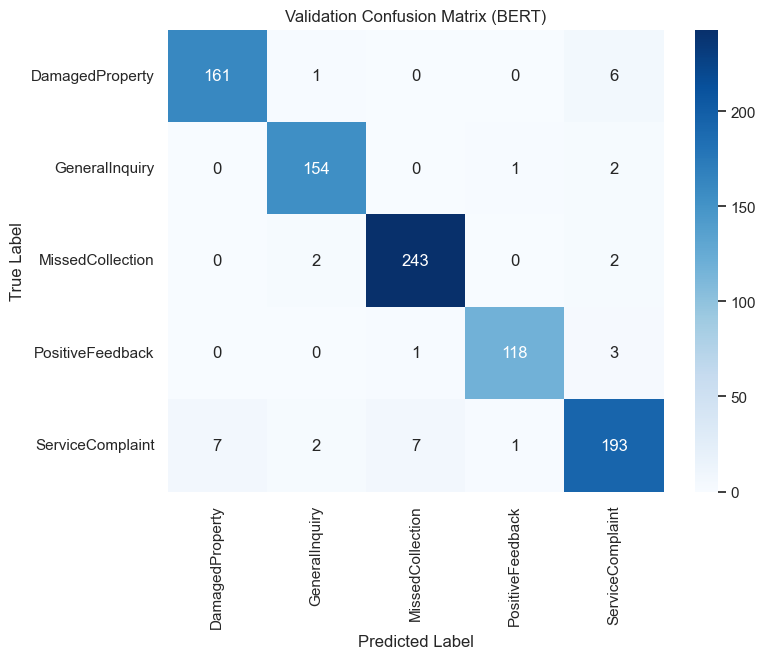

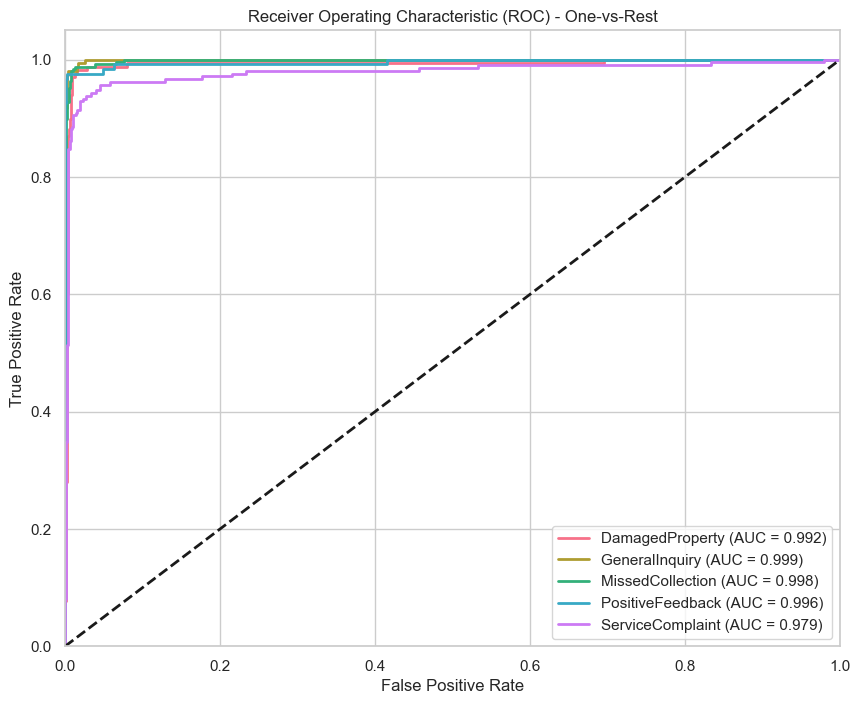


ROC AUC Scores Table:


,Class,ROC AUC Score
0,GeneralInquiry,0.999454
1,MissedCollection,0.998157
2,PositiveFeedback,0.995608
3,DamagedProperty,0.992001
4,ServiceComplaint,0.978606


In [10]:
# Cell 9: Final Evaluation, Confusion Matrix, and ROC Analysis
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Standard Evaluation
val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

print(f'Final Validation Accuracy: {val_acc:.4f}')
print('\nClassification Report:')
print(classification_report(val_labels, val_preds, target_names=labels))

# 2. Visualise the Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix (BERT)')
plt.show()

# 3. Gather probabilities for ROC Analysis
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for batch in val_loader:
        # Extract from dictionary and move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)
        
        # Pass input_ids and attention_mask to BERT
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(logits, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels_batch.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Binarise the labels for One-vs-Rest ROC calculation
n_classes = len(labels)
y_test_bin = label_binarize(all_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 8))
colors = sns.color_palette("husl", n_classes)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{labels[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest')
plt.legend(loc="lower right")
plt.show()

# 5. Display the ROC AUC Table
roc_table = pd.DataFrame({
    'Class': labels,
    'ROC AUC Score': [roc_auc[i] for i in range(n_classes)]
})

# Sort the table from highest performing to lowest performing
roc_table = roc_table.sort_values(by='ROC AUC Score', ascending=False).reset_index(drop=True)

print("\nROC AUC Scores Table:")
display(roc_table) # Use print(roc_table) if you are not in a Jupyter environment

In [11]:
# Cell 10: Inference helpers and demonstrations

# Reload checkpoint from disk
ckpt = torch.load(ckpt_path, map_location=device)

# 1. Re-initialise the BERT model instead of the custom Transformer
inference_model = BertClassifier(
    model_name='bert-base-uncased',
    num_classes=len(ckpt['idx2label']),
    dropout=0.2
).to(device)

# Load the trained weights
inference_model.load_state_dict(ckpt['model_state'])
inference_model.eval()

# Retrieve necessary metadata from the checkpoint
inf_idx2label = ckpt['idx2label']
INF_MAX_LEN = ckpt.get('max_len', 76) # Defaulting to your 95th percentile EDA if missing

def predict(text):
    # 2. Use the BertTokenizer to encode the text exactly as we did in training
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=INF_MAX_LEN,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    
    # 3. Move both input IDs and attention masks to the device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        # 4. Pass inputs to the model
        logits = inference_model(input_ids=input_ids, attention_mask=attention_mask)
        p = torch.softmax(logits, dim=1)[0]
        pred = p.argmax().item()
        
        return inf_idx2label[pred], p[pred].item()

# Test the inference pipeline
examples = [
    "My bin wasn't emptied today and it's overflowing",
    "Your driver broke my gate during collection",
    "Love the service — drivers are always friendly!",
    "Do you collect batteries?",
    "The crew left my bin on the pavement blocking the path"
]

print("Predictions:")
for ex in examples:
    label, score = predict(ex)
    print(f"[{score:.2f}] {label.upper()} <- '{ex}'")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9093.81it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predictions:
[0.93] MISSEDCOLLECTION <- 'My bin wasn't emptied today and it's overflowing'
[0.93] DAMAGEDPROPERTY <- 'Your driver broke my gate during collection'
[0.94] POSITIVEFEEDBACK <- 'Love the service — drivers are always friendly!'
[0.92] GENERALINQUIRY <- 'Do you collect batteries?'
[0.93] SERVICECOMPLAINT <- 'The crew left my bin on the pavement blocking the path'
